In [1]:
pip install seaborn plotly

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('visuals', exist_ok=True)

df = pd.read_csv('data/cleaned/upi_clean.csv',
                 parse_dates=['timestamp'])
df_all = pd.read_csv('data/cleaned/upi_all_statuses.csv',
                     parse_dates=['timestamp'])
print(df.shape)

(8786, 17)


/var/folders/wc/bhr9dtq56ps2t49_dh9yydf40000gn/T/ipykernel_49905/1448235358.py:21: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wc/bhr9dtq56ps2t49_dh9yydf40000gn/T/ipykernel_49905/1448235358.py:22: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('visuals/01_category_breakdown.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


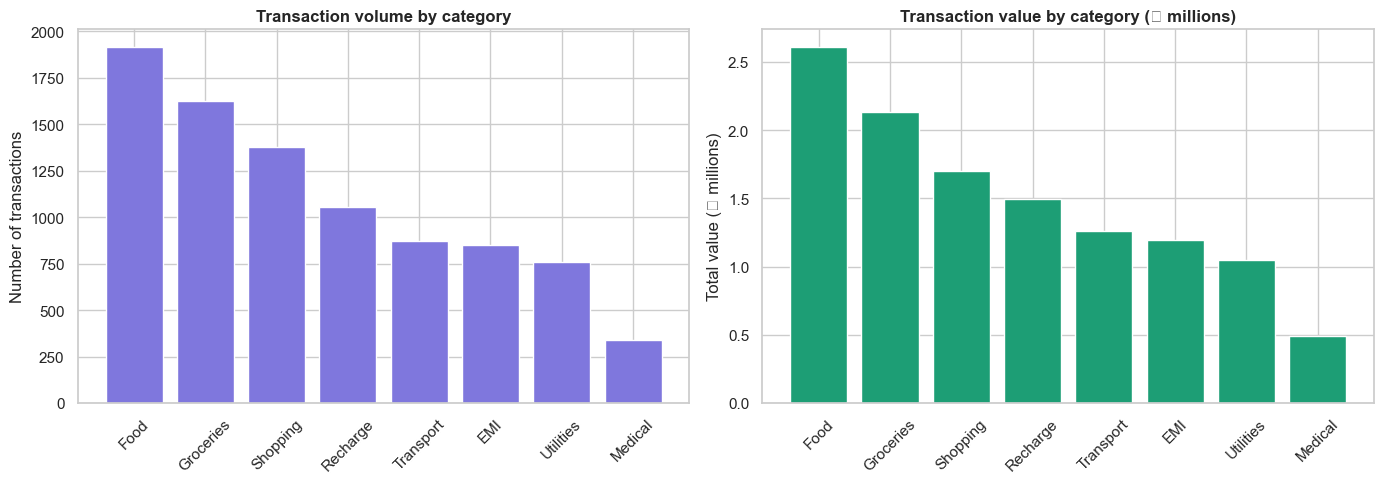

In [2]:
cat = df.groupby('merchant_category').agg(
    txn_count=('transaction_id','count'),
    total_value=('amount','sum'),
    avg_value=('amount','mean')
).sort_values('total_value', ascending=False).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Volume
ax1.bar(cat['merchant_category'], cat['txn_count'], color='#7F77DD')
ax1.set_title('Transaction volume by category', fontweight='bold')
ax1.set_ylabel('Number of transactions')
ax1.tick_params(axis='x', rotation=45)

# Value
ax2.bar(cat['merchant_category'], cat['total_value']/1e6, color='#1D9E75')
ax2.set_title('Transaction value by category (₹ millions)', fontweight='bold')
ax2.set_ylabel('Total value (₹ millions)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('visuals/01_category_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

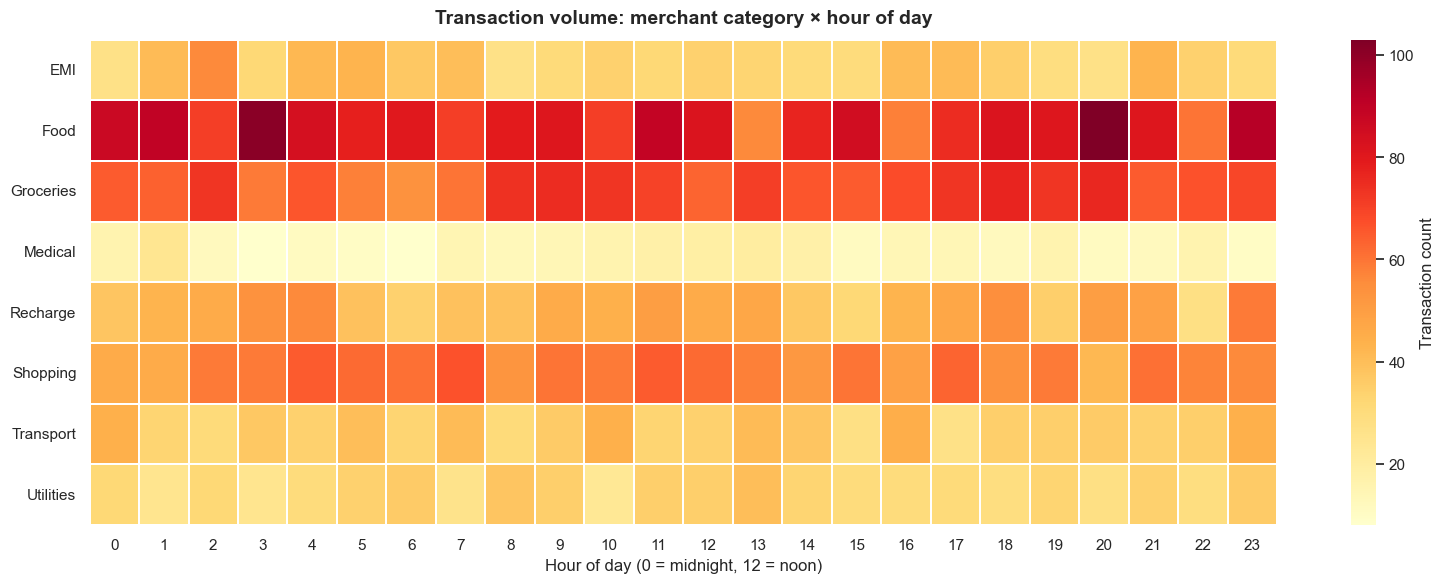

In [3]:
pivot = df.pivot_table(
    index='merchant_category',
    columns='hour',
    values='transaction_id',
    aggfunc='count'
).fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Transaction count'})
ax.set_title('Transaction volume: merchant category × hour of day',fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of day (0 = midnight, 12 = noon)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('visuals/02_category_hour_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

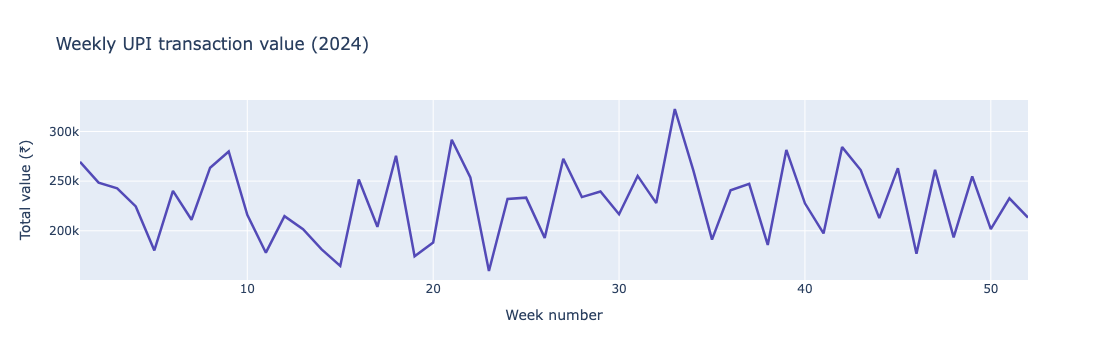

In [4]:
weekly = df.groupby('week').agg(
    txns=('transaction_id','count'),
    revenue=('amount','sum')
).reset_index()

fig = px.line(weekly, x='week', y='revenue',
              title='Weekly UPI transaction value (2024)',
              labels={'revenue':'Total value (₹)','week':'Week number'},
              color_discrete_sequence=['#534AB7'])
fig.update_traces(line_width=2.5)
fig.update_layout(hovermode='x unified')
fig.write_html('visuals/03_weekly_trend.html')
fig.show()

  city_tier    avg_spend  txns_per_user  failure_rate
0    Tier 1  1355.263718            7.8      9.431844
1    Tier 2  1343.876250            6.3      8.983385
2    Tier 3  1387.993218            3.6      9.368737


/var/folders/wc/bhr9dtq56ps2t49_dh9yydf40000gn/T/ipykernel_49905/2126727251.py:11: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



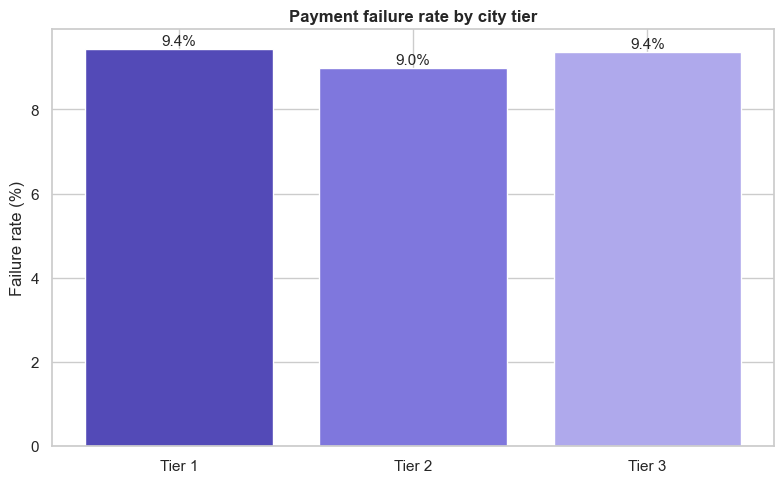

In [5]:
# Spending by tier
tier_ok = df.groupby('city_tier').agg(
    avg_spend=('amount','mean'),
    total_txns=('transaction_id','count'),
    unique_users=('user_id','nunique')
).reset_index()
tier_ok['txns_per_user'] = (tier_ok['total_txns'] /
                             tier_ok['unique_users']).round(1)

# Failure rate by tier (use full df)
fail = df_all.groupby('city_tier').apply(
    lambda x: (x['payment_status']=='Failed').mean()*100
).reset_index(name='failure_rate')

tier = tier_ok.merge(fail, on='city_tier')
print(tier[['city_tier','avg_spend','txns_per_user','failure_rate']])

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(tier['city_tier'], tier['failure_rate'],
              color=['#534AB7','#7F77DD','#AFA9EC'])
ax.set_title('Payment failure rate by city tier', fontweight='bold')
ax.set_ylabel('Failure rate (%)')
for bar, val in zip(bars, tier['failure_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('visuals/04_city_tier_failure.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/wc/bhr9dtq56ps2t49_dh9yydf40000gn/T/ipykernel_49905/4264352726.py:16: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.

/var/folders/wc/bhr9dtq56ps2t49_dh9yydf40000gn/T/ipykernel_49905/4264352726.py:17: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.



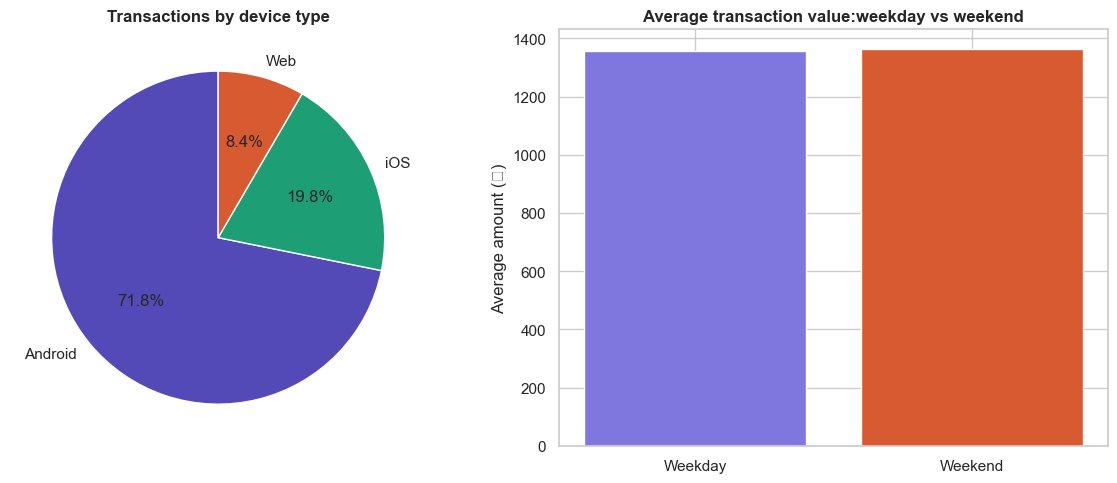

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Device split
dev = df['device_type'].value_counts()
ax1.pie(dev, labels=dev.index, autopct='%1.1f%%',
        colors=['#534AB7','#1D9E75','#D85A30'], startangle=90)
ax1.set_title('Transactions by device type', fontweight='bold')

# Weekend vs weekday avg spend
wk = df.groupby('is_weekend')['amount'].mean().reset_index()
wk['label'] = wk['is_weekend'].map({False:'Weekday', True:'Weekend'})
ax2.bar(wk['label'], wk['amount'], color=['#7F77DD','#D85A30'])
ax2.set_title('Average transaction value:weekday vs weekend', fontweight='bold')
ax2.set_ylabel('Average amount (₹)')

plt.tight_layout()
plt.savefig('visuals/05_device_weekend.png', dpi=150, bbox_inches='tight')
plt.show()